In [ ]:
####################################################################################################################################################


from astropy.io import fits

# Opening the STIX FITS file
file_path = "solo_L1_stix-sci-xray-cpd_20240514T034356-20240514T051641_V02_2405148542-53652.fits" 
hdul = fits.open(file_path)

# Checking structure
hdul.info()

# Displaying column names of the main data table
stix_data = hdul[2].data 

print("Available columns:", stix_data.columns.names)

#print(stix_data['e_high'])



Filename: solo_L1_stix-sci-xray-cpd_20240514T034356-20240514T051641_V02_2405148542-53652.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      76   ()      
  1  CONTROL       1 BinTableHDU    103   1R x 12C   [I, I, J, 1472I, B, 1472I, 96A, 73A, 3B, 3B, 33B, D]   
  2  DATA          1 BinTableHDU    109   1298R x 11C   [J, J, B, 12B, 32B, B, 16J, 16E, 4352I, 4352E, B]   
  3  IDB_VERSIONS    1 BinTableHDU     36   1R x 3C   [7A, D, D]   
  4  ENERGIES      1 BinTableHDU     36   17R x 3C   [B, E, E]   
Available columns: ['time', 'timedel', 'rcr', 'pixel_masks', 'detector_masks', 'num_pixel_sets', 'triggers', 'triggers_comp_err', 'counts', 'counts_comp_err', 'control_index']


In [8]:
import numpy as np

# Loading the main science data table (Check HDU index where the science data is stored)

# stix_data = hdul[2].data  # Usually, the main data is in the first extension

# Extract time, photon flux, and energy bin edges
time_data = stix_data["time"]       # Time array
photon_flux = stix_data["counts"]      # Flux array
energy_bins = hdul[4].data["e_low"]  # Energy bin lower edges

# Printing some sample values
print("Time Data:", time_data[:5])
print("Photon Flux:", photon_flux[:5])
print("Energy Bins:", energy_bins)

hdul.close()

Time Data: [ 170  695 1420 2020 2610]
Photon Flux: [[[[ 2  1  2 ...  0  0  1]
   [ 5  2  2 ...  0  0  0]
   [ 0  2  5 ...  0  1  0]
   ...
   [ 1  4  2 ...  0  0  0]
   [ 2  2  2 ...  0  1  0]
   [ 1  3  2 ...  0  0  0]]

  [[ 1  2  1 ...  0  0  0]
   [ 1  1  1 ...  0  0  0]
   [ 0  0  2 ...  0  0  0]
   ...
   [ 1  1  0 ...  0  0  0]
   [ 1  0  1 ...  0  0  0]
   [ 1  3  3 ...  0  0  0]]

  [[ 1  4  3 ...  0  0  0]
   [ 0  2  4 ...  0  1  0]
   [ 0  0  1 ...  0  0  0]
   ...
   [ 0  3  4 ...  0  0  0]
   [ 0  2  2 ...  1  0  0]
   [ 2  1  6 ...  0  0  0]]

  ...

  [[ 3  2  3 ...  0  0  0]
   [ 0  1  2 ...  0  0  1]
   [ 2  4  5 ...  0  0  0]
   ...
   [ 0  6  1 ...  0  0  0]
   [ 2  1  0 ...  0  0  0]
   [ 1  2  5 ...  0  0  0]]

  [[ 0  1  2 ...  0  0  0]
   [ 0  0  1 ...  0  0  0]
   [ 1  2  1 ...  0  0  0]
   ...
   [ 0  2  1 ...  0  0  0]
   [ 0  2  2 ...  0  0  0]
   [ 0  1  3 ...  0  1  0]]

  [[ 1  1  3 ...  0  0  0]
   [ 1  0  3 ...  0  0  0]
   [ 2  1  5 ...  0  0  0]
   ...

In [13]:
from astropy.time import Time, TimeDelta

# Define the start and end time in UTC format
start_time = Time("2024-05-14T04:00:00")  
end_time = Time("2024-05-14T06:00:00")

# Convert FITS time (usually in MET or MJD format) to standard time
print(time_data.astype(float)[0])   # checking the time data value

fits_time = start_time + TimeDelta(time_data, format="sec") # Modifying format
print(fits_time[0])

# Time filter
time_mask = (fits_time >= start_time) & (fits_time <= end_time)
print(time_mask)

# Filter data
selected_time = fits_time[time_mask]
selected_flux = photon_flux[time_mask]

#selected_energy = energy_bins[time_mask]

print("Filtered Time:", selected_time[:5])
print("Filtered Photon Flux:", selected_flux[:5])


170.0
2024-05-14T04:02:50.000
[ True  True  True ... False False False]
Filtered Time: ['2024-05-14T04:02:50.000' '2024-05-14T04:11:35.000'
 '2024-05-14T04:23:40.000' '2024-05-14T04:33:40.000'
 '2024-05-14T04:43:30.000']
Filtered Photon Flux: [[[[ 2  1  2 ...  0  0  1]
   [ 5  2  2 ...  0  0  0]
   [ 0  2  5 ...  0  1  0]
   ...
   [ 1  4  2 ...  0  0  0]
   [ 2  2  2 ...  0  1  0]
   [ 1  3  2 ...  0  0  0]]

  [[ 1  2  1 ...  0  0  0]
   [ 1  1  1 ...  0  0  0]
   [ 0  0  2 ...  0  0  0]
   ...
   [ 1  1  0 ...  0  0  0]
   [ 1  0  1 ...  0  0  0]
   [ 1  3  3 ...  0  0  0]]

  [[ 1  4  3 ...  0  0  0]
   [ 0  2  4 ...  0  1  0]
   [ 0  0  1 ...  0  0  0]
   ...
   [ 0  3  4 ...  0  0  0]
   [ 0  2  2 ...  1  0  0]
   [ 2  1  6 ...  0  0  0]]

  ...

  [[ 3  2  3 ...  0  0  0]
   [ 0  1  2 ...  0  0  1]
   [ 2  4  5 ...  0  0  0]
   ...
   [ 0  6  1 ...  0  0  0]
   [ 2  1  0 ...  0  0  0]
   [ 1  2  5 ...  0  0  0]]

  [[ 0  1  2 ...  0  0  0]
   [ 0  0  1 ...  0  0  0]
   [ 1  2  1

ValueError: x and y can be no greater than 2D, but have shapes (11,) and (11, 32, 8, 17)

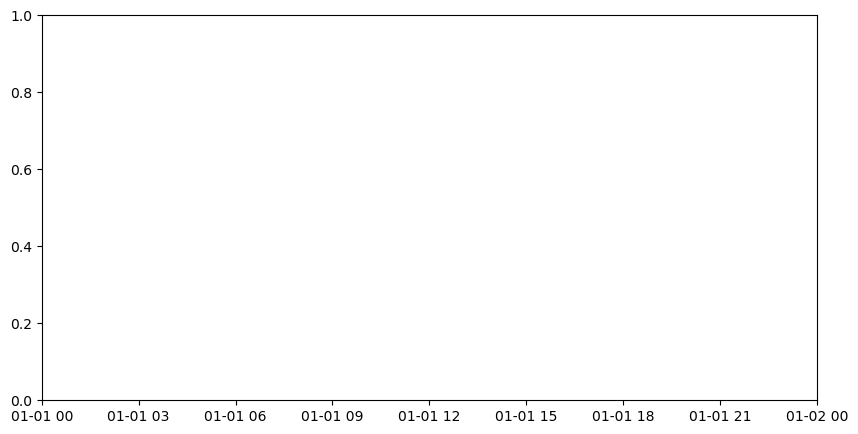

In [14]:
# Plot Photon Flux vs Time

selected_time_plot = selected_time.datetime

plt.figure(figsize=(10, 5))
plt.plot(selected_time_plot, selected_flux, marker='o', linestyle='-')
plt.xlabel("Time (UTC)")
plt.ylabel("Photon Flux")
plt.title("STIX Photon Flux Over Selected Time Range")
plt.grid()
plt.show()

TypeError: only length-1 arrays can be converted to Python scalars

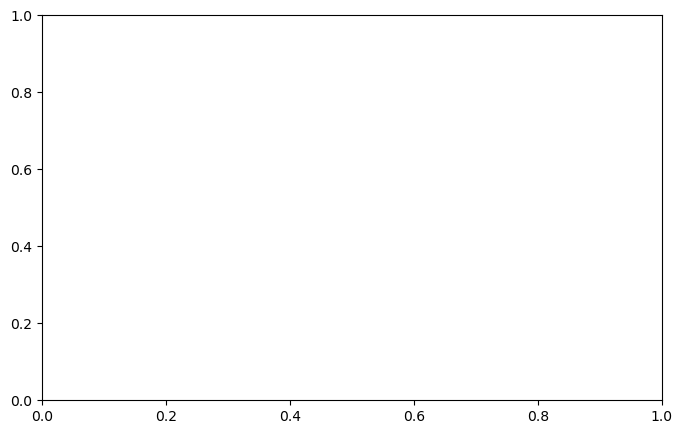

In [15]:
# Plot Photon Flux vs Time

plt.figure(figsize=(8, 5))
plt.bar(energy_bins, selected_flux.mean(axis=0), width=0.5, align='edge', alpha=0.7)
plt.xlabel("Energy (keV)")
plt.ylabel("Mean Photon Flux")
plt.title("STIX Energy Spectrum")
plt.grid()
plt.show()


In [107]:
print("Shape of selected_flux:", selected_flux.shape)
print(energy_bins.shape)
print(selected_flux.mean(axis=(0,1,2)).shape)
print(selected_flux.mean(axis=(0,1,2)))
print(energy_bins)

Shape of selected_flux: (11, 32, 8, 17)
(17,)
(17,)
[1.59517045 2.96946023 3.82848011 2.29865057 0.9921875  0.34446023
 0.16051136 0.12109375 0.09055398 0.0415483  0.03053977 0.02166193
 0.05965909 0.05255682 0.0625     0.13849432 0.20667614]
[ 4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 18. 20. 22. 25.]
